<a href="https://colab.research.google.com/github/yukinaga/minnano_kaggle/blob/main/section_4/02_automl_houseprices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 概要
顧客離脱の予測を行う。


## PyCaretのインストール
AutoMLをサポートするライブラリ、PyCaretをバージョンを指定してインストールします。

In [1]:
# !pip install numpy==1.21.4 numba==0.53 # すでに入っている
!pip install pycaret
!pip install pandas-profiling==3.1.0 

  Using cached joblib-1.3.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached joblib-1.3.2-py3-none-any.whl (302 kB)
Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl (12 kB)
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 2.0.1
    Uninstalling MarkupSafe-2.0.1:
      Successfully uninstalled MarkupSafe-2.0.1
  Attempting uninstall: joblib
    Found existing installation: joblib 1.0.1
    Uninstalling joblib-1.0.1:
      Successfully uninstalled joblib-1.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [joblib]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.1.0 requires joblib~=1.0.1, but you have joblib 1.3.2 which is incompatible.
pandas-profiling 3.1.0 requires markupsafe~=2.0.1, but you have markupsafe 3.0.3 

## データの読み込み

In [5]:
# PyCaretを使用して、データの前処理、特徴量エンジニアリング、モデルのトレーニング、評価を行う

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data_train = pd.read_csv('../data/train.csv')
data_test = pd.read_csv('../data/test.csv')

print('train', data_train.shape, 'test', data_test.shape)
data_train.tail()

train (594194, 21) test (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


## 環境の設定
PyCaretの環境を設定します。 
setup関数はPyCaretの環境を初期化しますが、PyCaretの他の関数を実行する前に呼び出す必要があります。      
データの型に問題が無ければ、空白を入力することで設定を完了することができます。  


In [6]:
from pycaret.classification import setup

# 分類タスクとしてセットアップ（VS Codeでの表示不具合を避けるためhtml=False）
clf = setup(
    data=data_train,
    target="Churn",
    session_id=123,
    fold=5,
    html=False,
    log_experiment=False,
    verbose=False,
)

## モデルの比較
様々なモデルを比較して、性能を評価します。  
compare_models関数は、ライブラリ内のすべてのモデルを使って訓練を行い、スコアを評価します。  

In [7]:
from pycaret.classification import compare_models, pull

# 重い全探索を避けるため、まず主要モデルのみ比較
best_model = compare_models(
    include=["lr", "rf", "et", "gbc", "lightgbm"],
    fold=5,
    turbo=True,
    sort="AUC",
    verbose=False,
)

leaderboard = pull()
display(leaderboard.head(10))
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8602,0.9150,0.8602,0.8561,0.8577,0.5854,0.5866,1.680
gbc,Gradient Boosting Classifier,0.8590,0.9136,0.8590,0.8544,0.8560,0.5797,0.5813,9.486
lr,Logistic Regression,0.8540,0.9075,0.8540,0.8517,0.8527,0.5745,0.5747,4.372
rf,Random Forest Classifier,0.8492,0.9007,0.8492,0.8439,0.8458,0.5493,0.5510,5.072
et,Extra Trees Classifier,0.8397,0.8896,0.8397,0.8350,0.8369,0.5253,0.5263,5.200


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


わずか1行のコードで、15以上の機械学習モデルを訓練し、評価することができました。  
  
最もスコアの良いモデルの概要を表示します。


In [8]:
print(best_model)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


## モデルの作成
models関数により、全ての使用可能な機械学習モデルを確認することができます。

In [9]:
from pycaret.classification import models

models()  # 機械学習モデルの一覧

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


create_model関数は、「交差検証」を用いて個別のモデルの訓練と評価を行います。  
今回は、先程最も精度が高かった「勾配ブースティング」による回帰（Gradient Boosting Regressor）のモデルを作成します。  


In [10]:
from pycaret.classification import create_model

gbc = create_model("gbc")  # 勾配ブースティング分類モデルを作成

      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8591  0.9134  0.8591  0.8546  0.8562  0.5802  0.5817
1       0.8596  0.9138  0.8596  0.8551  0.8567  0.5815  0.5831
2       0.8584  0.9123  0.8584  0.8537  0.8554  0.5776  0.5793
3       0.8579  0.9134  0.8579  0.8536  0.8552  0.5781  0.5794
4       0.8600  0.9151  0.8600  0.8551  0.8567  0.5810  0.5829
Mean    0.8590  0.9136  0.8590  0.8544  0.8560  0.5797  0.5813
Std     0.0008  0.0009  0.0008  0.0006  0.0006  0.0016  0.0017


訓練済みモデルの概要を表示します。  

In [11]:
print(gbc)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=123, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


## ハイパーパラメータの調整
tune_model関数を使用し、ハイパーパラメータを最適化します。

In [12]:
from pycaret.classification import tune_model

tuned_gbc = tune_model(gbc)  # ハイパーパラメータの調整

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.8607  0.9152  0.8607  0.8571  0.8585  0.5888  0.5897
1       0.8623  0.9149  0.8623  0.8586  0.8600  0.5927  0.5937
2       0.8596  0.9143  0.8596  0.8557  0.8572  0.5842  0.5853
3       0.8606  0.9151  0.8606  0.8570  0.8584  0.5884  0.5893
4       0.8620  0.9165  0.8620  0.8576  0.8591  0.5889  0.5904
Mean    0.8611  0.9152  0.8611  0.8572  0.8587  0.5886  0.5897
Std     0.0010  0.0007  0.0010  0.0009  0.0009  0.0027  0.0027


ハイパーパラメータを調整済みの、モデルの概要を表示します。  

In [13]:
print(tuned_gbc)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.15, loss='log_loss', max_depth=7,
                           max_features=1.0, max_leaf_nodes=None,
                           min_impurity_decrease=0.02, min_samples_leaf=5,
                           min_samples_split=5, min_weight_fraction_leaf=0.0,
                           n_estimators=230, n_iter_no_change=None,
                           random_state=123, subsample=0.85, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


## モデルを評価する
plot_model関数を使い、各特徴量の重要度をプロットします。

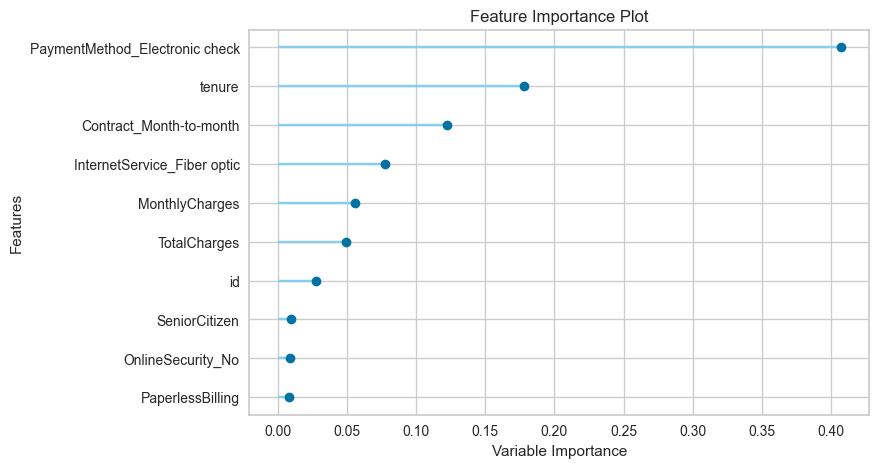

In [14]:
from pycaret.classification import plot_model

plot_model(tuned_gbc, plot="feature")  # 各特徴の重要度をプロット

## 本番用のモデルを作成
`finalize_model`関数により全ての訓練データを使ってモデルを訓練し、本番用のモデルを作成します。   

In [15]:
from pycaret.classification import finalize_model

final_gbc = finalize_model(tuned_gbc)
print(final_gbc)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['id', 'SeniorCitizen', 'tenure',
                                             'MonthlyCharges', 'TotalCharges'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_...
                                            criterion='friedman_mse', init=None,
                                            learning_rate=0.15, loss='log_loss',
                                            max_depth=7, max

## 提出用のデータを作成
テストデータを使って予測を行います。  
予測結果には、予測値を表す「Label」列が含まれます。

In [16]:
from pycaret.classification import predict_model

test_pred = predict_model(final_gbc, data=data_test)  # 予測
test_pred.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,prediction_label,prediction_score
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Two year,Yes,Electronic check,115.550003,8061.500000,No,0.9840
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.799999,1336.500000,No,0.9995
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.549999,633.549988,No,0.9046
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.099998,6457.149902,No,0.9971
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Month-to-month,No,Electronic check,90.349998,1233.650024,Yes,0.6475


形式を整えた上で、Kaggleに提出するためのcsvファイルを保存します。

In [17]:
# 形式を整える
subm_data = test_pred[["id", "prediction_label"]]  # 列を抜き出す
subm_data = subm_data.rename(columns={"prediction_label": "Churn"})  # 列名の変更

# "Churn"はYes/Noの文字列で出力されるため、数値に変換（Yes=1, No=0）
subm_data["Churn"] = subm_data["Churn"].map({"Yes": 1, "No": 0})
# 提出用のcsvファイルを保存
subm_data.to_csv("submission_churn.csv", index=False)

subm_data

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,1
...,...,...
254650,848844,0
254651,848845,1
254652,848846,0
254653,848847,0
